# Stillwater SewerTris Project Workflow

This notebook implements the Stillwater SewerTris workflow using the project-oriented API. A `SewerTrisProject` object owns the output directory, standard files, JSON metadata, and SWMM scenario folders. The physical Stillwater network is generated once from the shapefile domain, then a named scenario applies BWF/DWF, GWI, and RDII inputs for dynamic SWMM analysis.

The notebook follows the twelve SewerTris model implementation steps:

1. Urban Domain Definition: Defines the spatial modeling boundary using a vector polygon or raster mask and establishes the sewer outlet location.

2. Tetris Block Definition: Specifies modular tetromino building blocks (I, O, T, S, Z, J, L, BO shapes) that form the geometric basis of the synthetic urban layout.

3. Stochastic Tetris Completion: Populates the domain using randomized block placement to generate heterogeneous but coherent urban configurations.

4. Road Network Extraction: Derives a synthetic road network from block boundaries, ensuring topological consistency with urban structure.

5. Land-Use Assignment: Assigns residential, commercial, industrial, public, and recreational land uses using rule-based or user-defined allocation strategies.

6. Synthetic DEM Generation: Creates a hydraulically consistent Digital Elevation Model (DEM) enforcing global drainage toward the outlet.

7. Sewer Network Generation: Constructs a gravity-driven, tree-structured sewer network aligned with roads and embedded within the DEM.

8. Sewer Flow Predesign: Computes baseline peak discharges combining Dry-Weather Flow (DWF), Groundwater Infiltration (GWI), and Rainfall-Derived Inflow and Infiltration (RDII).

9. Pipe Sizing and Hydraulic Properties: Assigns pipe diameters, roughness, and invert elevations using Manning-based design principles.

10. Dynamic Flow Input Definition: Specifies temporally resolved DWF, GWI, and RDII inputs, including rainfall forcing and spatial heterogeneity options.

11. EPA-SWMM Simulation: Performs unsteady hydraulic routing and enables component tagging (RAIN and DRY) for flow separation analysis.

12. Flow Output Decomposition: Extracts and decomposes total flows into DWF, RDII, and residual GWI components for benchmarking and diagnostics.


## Setup: Import Libraries and Create a Project

The notebook imports only the packages used directly in the cells. The modeling logic itself lives inside the refactored `sewertris` package, while the project object tracks paths, metadata, and scenario outputs.


In [1]:
from pathlib import Path
import importlib
import sys

import geopandas as gpd
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "Examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris

# Reload package modules during notebook-driven development so recent refactors are visible.
for _module_name in [
    "sewertris._deps",
    "sewertris.domain",
    "sewertris.layout",
    "sewertris.roads",
    "sewertris.topography",
    "sewertris.sewer_network",
    "sewertris.hydrology",
    "sewertris.design",
    "sewertris.swmm",
    "sewertris.plots",
    "sewertris.project",
    "sewertris",
]:
    if _module_name in sys.modules:
        importlib.reload(sys.modules[_module_name])

import sewertris as st

min_width = 100  # meters
project = st.SewerTrisProject(
    EXAMPLES_DIR / "output_example_2_project",
    cell_size_m=min_width,
    name="Stillwater SewerTris Project",
)
project.save()
print(f"Project metadata: {project.project_file}")


Project metadata: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewertris_project.json


## 1. Urban Domain Definition

The project builds the Stillwater domain mask from `input/domain_mask.shp`, stores the mask and geospatial grid metadata, and records this step in `sewertris_project.json`.


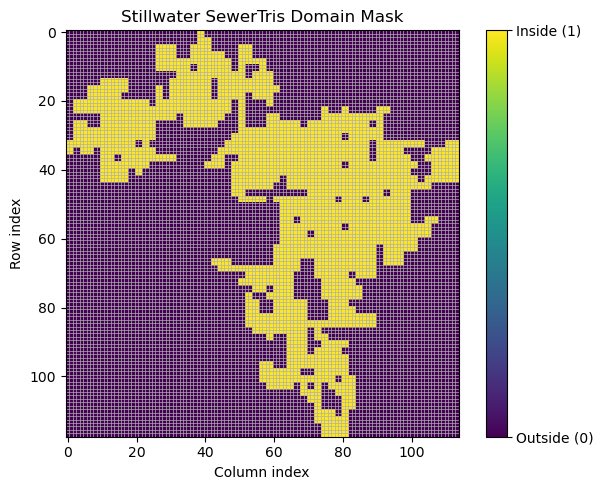

In [2]:
use_shapefile = True
shapefile_path = Path("input/domain_mask.shp")
if not shapefile_path.exists():
    shapefile_path = PROJECT_ROOT / "Examples" / "input" / "domain_mask.shp"

if use_shapefile:
    gdf_in = gpd.read_file(shapefile_path)
    cell_size = st.meters_to_crs_units(min_width, gdf_in.crs)
    domain_mask, grid_meta = project.build_domain_mask_from_shapefile(
        shapefile_path,
        cell_size_m=cell_size,
    )
else:
    domain_mask = np.array([
        [0,0,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
    ])
    grid_meta = dict(
        crs_out="EPSG:3857",
        origin_x=0,
        origin_y=0,
        cell_w=min_width,
        cell_h=min_width,
        rows=domain_mask.shape[0],
        cols=domain_mask.shape[1],
        flip_y=False,
    )
    project.define_domain(domain_mask=domain_mask, cell_size_m=min_width, grid_meta=grid_meta)

st.plot_domain_mask(domain_mask, title="Stillwater SewerTris Domain Mask")


## 2. Tetris Block Definition

Tetromino shapes and colors are stored in the project state. This uses the same full block library from `example_02_Stillwater_sewertris.ipynb`.


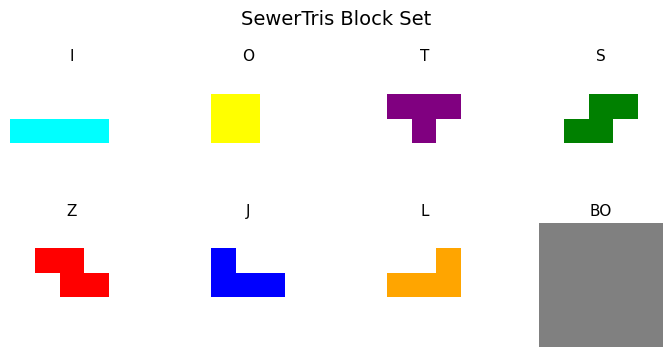

In [3]:
tetrominoes = {
    'I': [np.array([[1,1,1,1]]), np.array([[1],[1],[1],[1]])],
    'O': [np.array([[1,1],[1,1]])],
    'T': [np.array([[1,1,1],[0,1,0]]), np.array([[0,1],[1,1],[0,1]]), np.array([[0,1,0],[1,1,1]]), np.array([[1,0],[1,1],[1,0]])],
    'S': [np.array([[0,1,1],[1,1,0]]), np.array([[1,0],[1,1],[0,1]])],
    'Z': [np.array([[1,1,0],[0,1,1]]), np.array([[0,1],[1,1],[1,0]])],
    'J': [np.array([[1,0,0],[1,1,1]]), np.array([[1,1],[1,0],[1,0]]), np.array([[1,1,1],[0,0,1]]), np.array([[0,1],[0,1],[1,1]])],
    'L': [np.array([[0,0,1],[1,1,1]]), np.array([[1,0],[1,0],[1,1]]), np.array([[1,1,1],[1,0,0]]), np.array([[1,1],[0,1],[0,1]])],
    'BO': [np.array([[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]])],
}

tetromino_colors = {
    'I': 'cyan',
    'O': 'yellow',
    'T': 'purple',
    'S': 'green',
    'Z': 'red',
    'J': 'blue',
    'L': 'orange',
    'BO': 'grey',
}

project.define_tetrominoes(tetrominoes, tetromino_colors)
st.plot_tetromino_set(tetrominoes, tetromino_colors, ncols=4)


## 3. Stochastic Tetris Completion

The project fills the Stillwater domain and exports the generated block layout using the georeferenced grid metadata from the shapefile domain.


✅ Exported 1523 figures to /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/city_layout.gpkg
Total blocks: 1524
Layout blocks: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/city_layout.gpkg


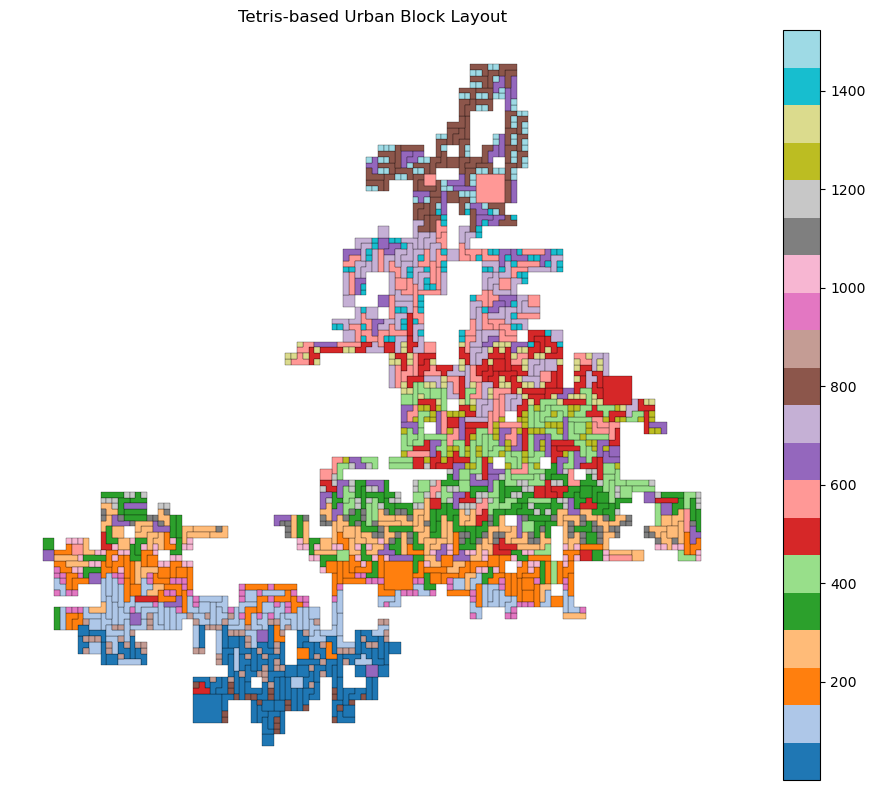

In [4]:
layout_seed = 1000 # Seed 1002 is good for testing bad convergance in previous method

filled_board, id_type_map, block_id = project.complete_tetris_layout(
    georeferenced=True,
    seed=layout_seed,
)

print("Total blocks:", len(np.unique(filled_board)))
print("Layout blocks:", project.layout_blocks_path)
st.plot_filled_board_shapefile(project.layout_blocks_path)


## 4. Road Network Extraction

The project derives road centerlines and polygons from the generated Stillwater layout and stores them at standard project paths.


[OK] Boundary lines written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/road_boundary_lines.gpkg
[OK] Outer shell polygon(s) written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/road_outer_shell.gpkg
Road centerlines: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/road_centerlines.gpkg
Road polygons: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/road_polygons.gpkg


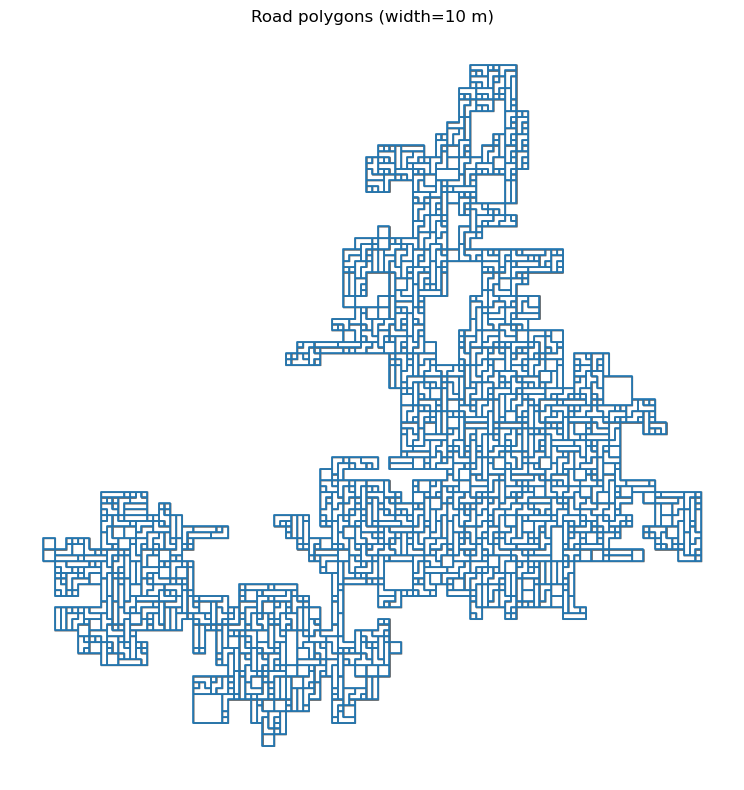

In [5]:
road_width = 10  # meters
road_lines, road_buffer, crs = project.generate_roads(
    road_width=road_width,
    simplify_tol=0.5,
)
project.extract_road_boundaries(keep_holes=False)

print("Road centerlines:", project.road_centerlines_path)
print("Road polygons:", project.road_polygons_path)
st.plot_roads(
    road_lines=road_lines,
    road_buffer=road_buffer,
    crs=crs,
    title=f"Road polygons (width={road_width} m)",
)


## 5. Land-Use Assignment

The project cuts blocks by the road network, assigns compact land-use categories, and writes the final block layer to `project.blocks_path`.


✅ Exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/city_blocks.gpkg
Land-use blocks: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/city_blocks.gpkg


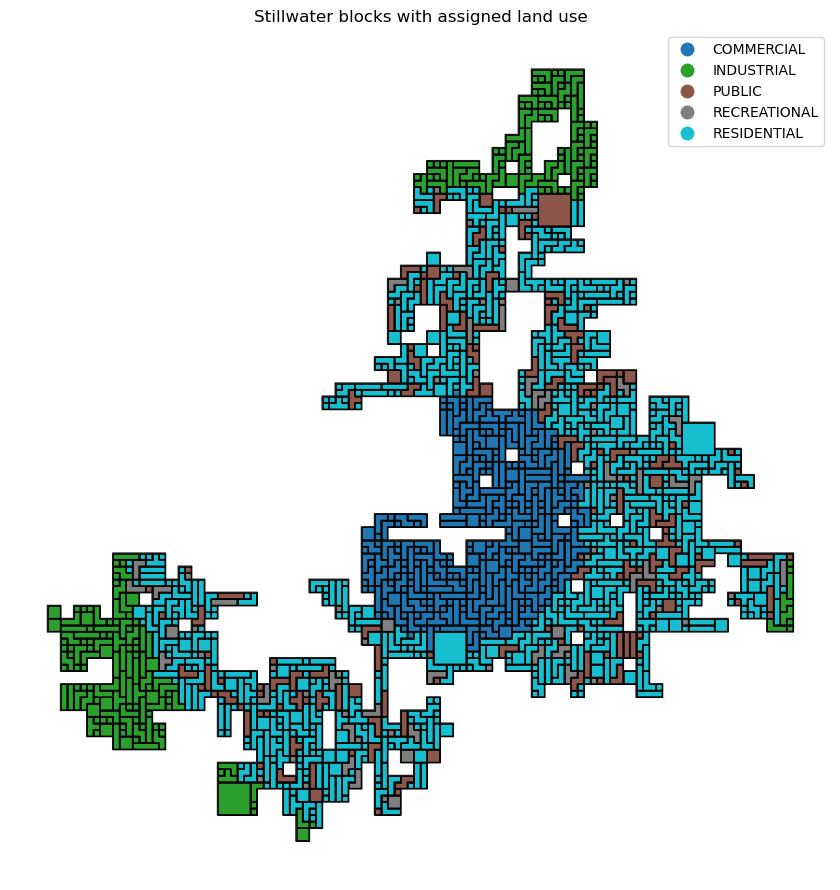

In [6]:
blocks_gdf = project.assign_land_use()
roads_gdf = gpd.read_file(project.road_polygons_path)
if roads_gdf.crs != blocks_gdf.crs:
    roads_gdf = roads_gdf.to_crs(blocks_gdf.crs)

print("Land-use blocks:", project.blocks_path)
st.plot_blocks_landuse(
    blocks_gdf=blocks_gdf,
    roads_gdf=roads_gdf,
    landuse_col="land_use",
    title="Stillwater blocks with assigned land use",
    savepath=project.path("blocks_landuse.png"),
)


## 6. Synthetic DEM Generation

The project builds the Stillwater DEM with the same elevation range, cell size, outlet direction, and smoothing settings used in `example_02`.


Original boundary CRS: EPSG:32614
Original roads CRS: EPSG:32614

Boundary extent:
X range: 667166.00 to 678576.00
Y range: 3994829.67 to 4006639.67
Boundary CRS: EPSG:32614
Boundary bounds: [ 667165.9958307  3994829.67323194  678575.9958307  4006639.67323194]
Grid shape: (1202, 1162)
Grid extent:
  X: 667060.00 to 678680.00
  Y: 3994720.00 to 4006740.00
Creating mask...
Processing row 0 of 1202
Processing row 100 of 1202
Processing row 200 of 1202
Processing row 300 of 1202
Processing row 400 of 1202
Processing row 500 of 1202
Processing row 600 of 1202
Processing row 700 of 1202
Processing row 800 of 1202
Processing row 900 of 1202
Processing row 1000 of 1202
Processing row 1100 of 1202
Processing row 1200 of 1202
Outlet cell: (1110, 591)
Computing geodesic distances...
Processing roads...


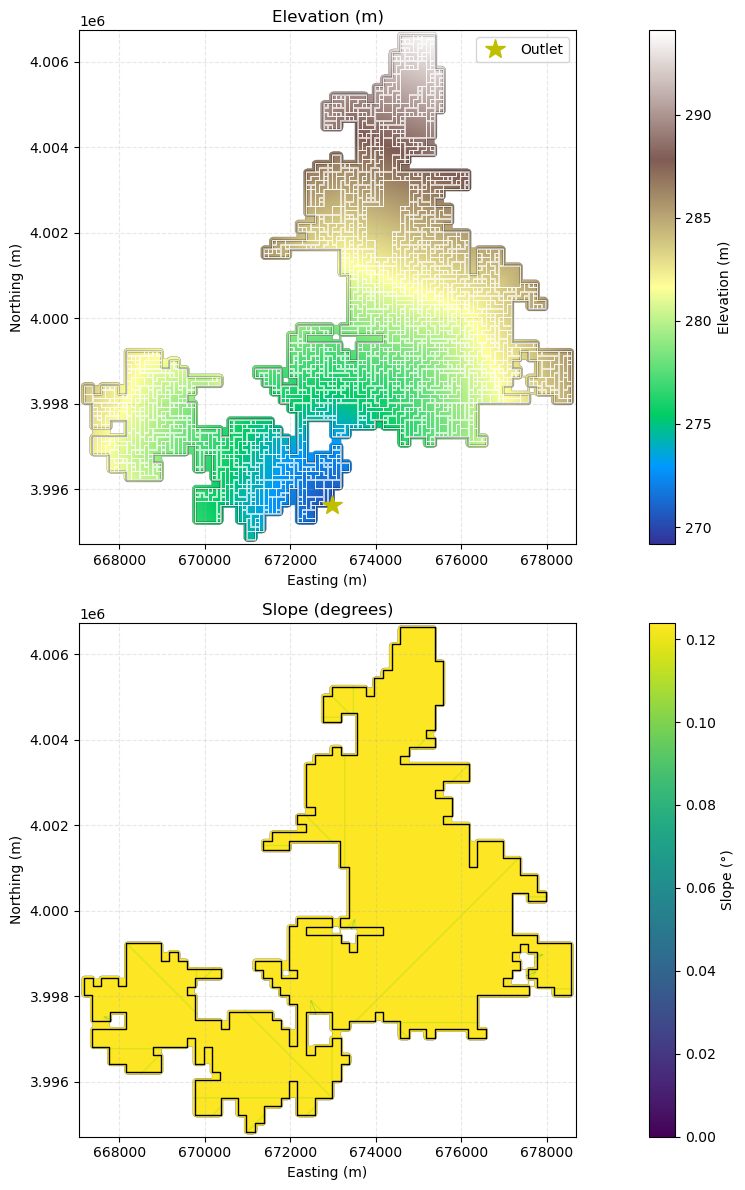


Terrain Statistics:
Elevation range: 269.17m - 294.09m
Mean elevation: 281.10m
Mean slope: 0.12°
Max slope: 2.50°

Drainage Statistics:
Points with proper drainage: 500309.0 out of 533617 (93.8%)
DEM: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/generated_topography.tif
DEM resolution: 10 m
Elevation range: 270 m - 290 m
Grid extent:
  X: 667060.00 to 678680.00
  Y: 4006740.00 to 3994720.00


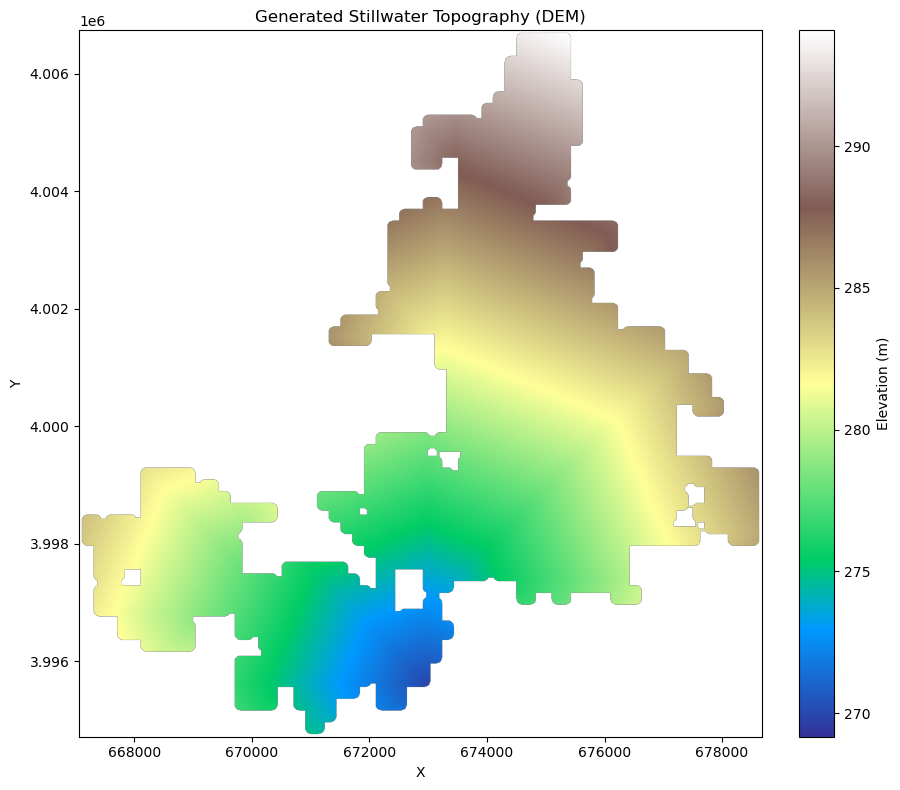

In [7]:
config = st.TopographyConfig(
    min_elevation=270,
    max_elevation=290,
    cell_size=10,
    outlet_direction='S',
    smoothing_factor=1,
)

elevation, xx, yy, mask = project.generate_topography(
    boundary_path=project.road_outer_shell_path,
    roads_path=project.road_polygons_path,
    config=config,
)

print("DEM:", project.dem_path)
print(f"DEM resolution: {config.cell_size} m")
print(f"Elevation range: {config.min_elevation} m - {config.max_elevation} m")
print("Grid extent:")
print(f"  X: {xx[0,0]:.2f} to {xx[0,-1]:.2f}")
print(f"  Y: {yy[0,0]:.2f} to {yy[-1,0]:.2f}")
st.plot_dem_tif(project.dem_path, title="Generated Stillwater Topography (DEM)", hillshade=False)


## 7. Sewer Network Generation

The project extracts manholes, generates main/secondary/tertiary gravity pipes with the same network parameters used in `example_02`, and embeds the network into the DEM to enforce positive slopes.


✅ Extracted 3473 manholes from road centerlines.
✅ Manholes exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/manholes.gpkg

Path Statistics:
Head: MH1914  →  Target: MH2191
Segments: 113
Total length: 15200.0 m
Total drop: 24.82 m
Avg slope: 0.152%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 1214 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
📊 V2 initial missing outlet pipes: 2145
V2 iteration 1: start=MH033, status=committed, chain_len=6, cost=953.14, remaining=2139
V2 iteration 2: start=MH039, status=committed, chain_len=7, cost=1131.85, remaining=2132
V2 iteration 3: start=MH045, status=committed, chain_len=28, cost=3415.98, remaining=2104
V2 iteration 4: start=MH057, status=committed, chain_len=10, cost=1714.69, remaining=2094
V2 iteration 5: start=MH079, status=committed, chain_len=23, cost=2800.00, remaining=2071
V2 iteration 6: start=MH107, status=committed, chain_len=1, cost=116.57, remaining=207

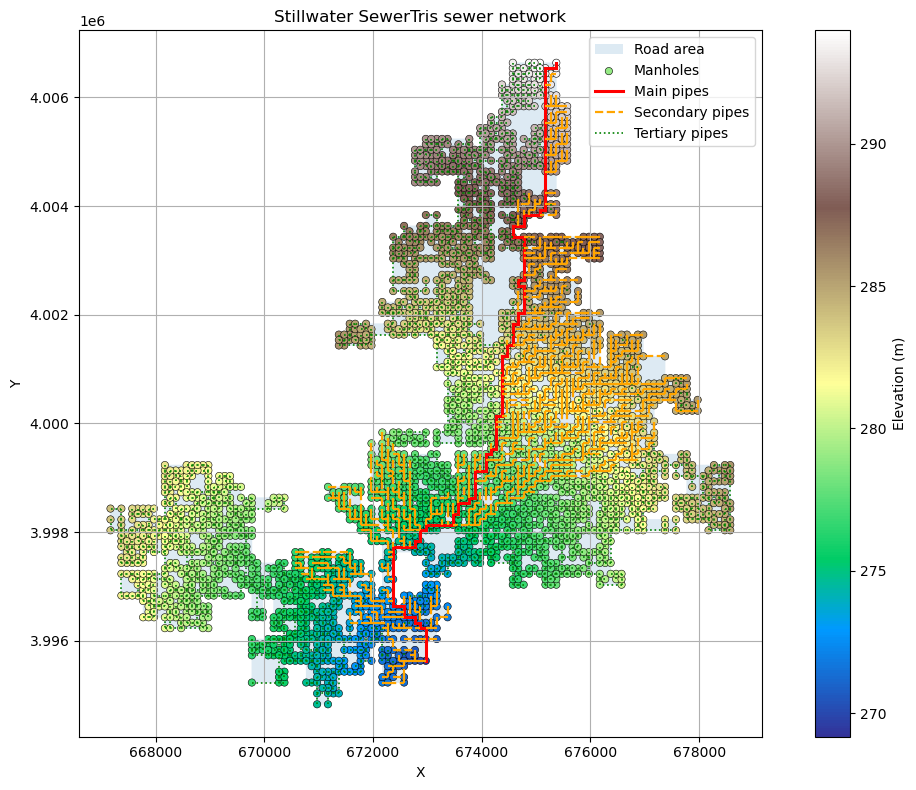

⚠️ Raster check: 3034 pipes have a local slope < Smin (e.g., idx=2622, slope=-0.000266).
Updated elevations for 3473/3473 manholes. Wrote: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/manholes.gpkg


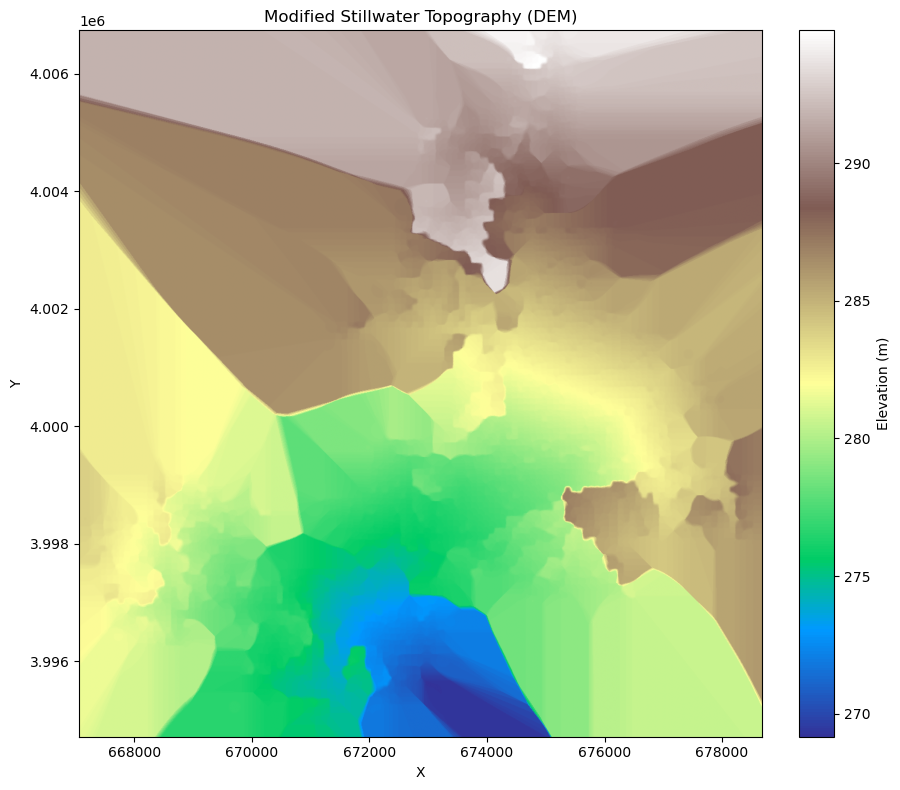

In [8]:
# gdf_pipes = project.generate_sewer_network(
#     road_width=road_width,
#     block_size=min_width * 2,
#     main_slope_tolerance=-0.01,
#     secondary_slope_tolerance=0.0,
#     prefer_slope=0.5,
#     tertiary_block_size=min_width * 10,
#     neighbor_radius_factor=1.5,
#     tertiary_min_pipe_length=1e-3,
#     point_on_line_tol=0.01,
#     max_search_depth=300,
# )

gdf_pipes = project.generate_sewer_network_V2(
    road_width=road_width,
    block_size=min_width * 2,
    main_slope_tolerance=-0.01,
    secondary_slope_tolerance=0.0,
    prefer_slope=0.5,
    tertiary_block_size=min_width * 10,
    neighbor_radius_factor=1.5,
    tertiary_min_pipe_length=1e-3,
    point_on_line_tol=0.01,

    # V2 tertiary slope behavior
    tertiary_adverse_slope_weight=200.0,
    tertiary_mild_adverse_slope=-0.005,
    tertiary_moderate_adverse_slope=-0.01,
    tertiary_severe_adverse_multiplier=8.0,
)


print("Pipes:", project.pipes_path)
print("Manholes:", project.manholes_path)

network_status = project.state["network_status"]
print("Main outlet ID:", network_status["main_outlet_id"])
print("Total manholes:", len(network_status["all_ids"]))
print("Nodes already touched by main+secondary:", len(network_status["nodes_in_network"]))
print("Manholes missing outlet pipe:", len(network_status["missing_outlet_ids"]))
print("First 20 missing:", network_status["missing_outlet_ids"][:20])
print("Duplicate sources:", network_status["duplicate_sources"][:20])

st.plot_sewer_network_all(
    manholes=project.state["manholes"],
    main_pipes=project.state["main_path"],
    secondary_pipes=project.state["secondary_pipes"],
    tertiary_pipes=project.state["tertiary_pipes"],
    unresolved=project.state["tertiary_unconnected"],
    road_buffer=project.state["road_buffer"],
    title="Stillwater SewerTris sewer network",
)

project.embed_sewer_network_in_dem(
    upstream_field="upstream_m",
    downstream_field="downstream_m",
    manhole_id_field="id",
    manhole_elev_field="elevation",
    type_field="type",
    tier_order=("main", "secondary", "tertiary"),
    Smin=0.001,
    densify_step_m=None,
    along_pipe_weight=2,
    idw_power=2.0,
    idw_k=12,
    idw_tile=1024,
    centerline_writeback=True,
    verify_on_raster=True,
)
st.plot_dem_tif(project.dem_path, title="Modified Stillwater Topography (DEM)", hillshade=False)


## 8. Sewer Flow Predesign

The project delineates subcatchments, assigns baseflow, computes peak flow, accumulates GWI and RDII, and writes predesign flow fields to the pipe layer.


In [9]:
LAND_USE_INFO = {
    'RESIDENTIAL': {'density': 60, 'demand': 100},
    'COMMERCIAL': {'density': 50, 'demand': 60},
    'INDUSTRIAL': {'density': 25, 'demand': 150},
    'PUBLIC': {'density': 20, 'demand': 100},
    'RECREATIONAL': {'density': 10, 'demand': 40},
}

predesign_pipes = project.predesign_flows(
    land_use_info=LAND_USE_INFO,
    gwi_factor_ls_per_m=0.0002,
    rdii_factor_ls_per_m2=0.00002,
    target_crs_m="EPSG:3857",
)
print("Subcatchments:", project.subcatchments_path)
print("Predesign pipes:", project.pipes_path)


✅ Sub-catchments saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_subcatchments.gpkg
✅ Updated pipe file saved: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_pipes.gpkg
Subcatchments: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_subcatchments.gpkg
Predesign pipes: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_pipes.gpkg


## 9. Pipe Sizing and Hydraulic Properties

The project assigns pipe slopes, materials, diameters, roughness, and invert elevations, then preprocesses the pipe and manhole layers for SWMM export.


✅ Pipe slopes assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_pipes.gpkg
✅ Materials and diameters assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_pipes.gpkg
✅ Invert elevations assigned and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_pipes.gpkg
✅ Pipes saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_pipes.gpkg
✅ Manholes saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/manholes.gpkg


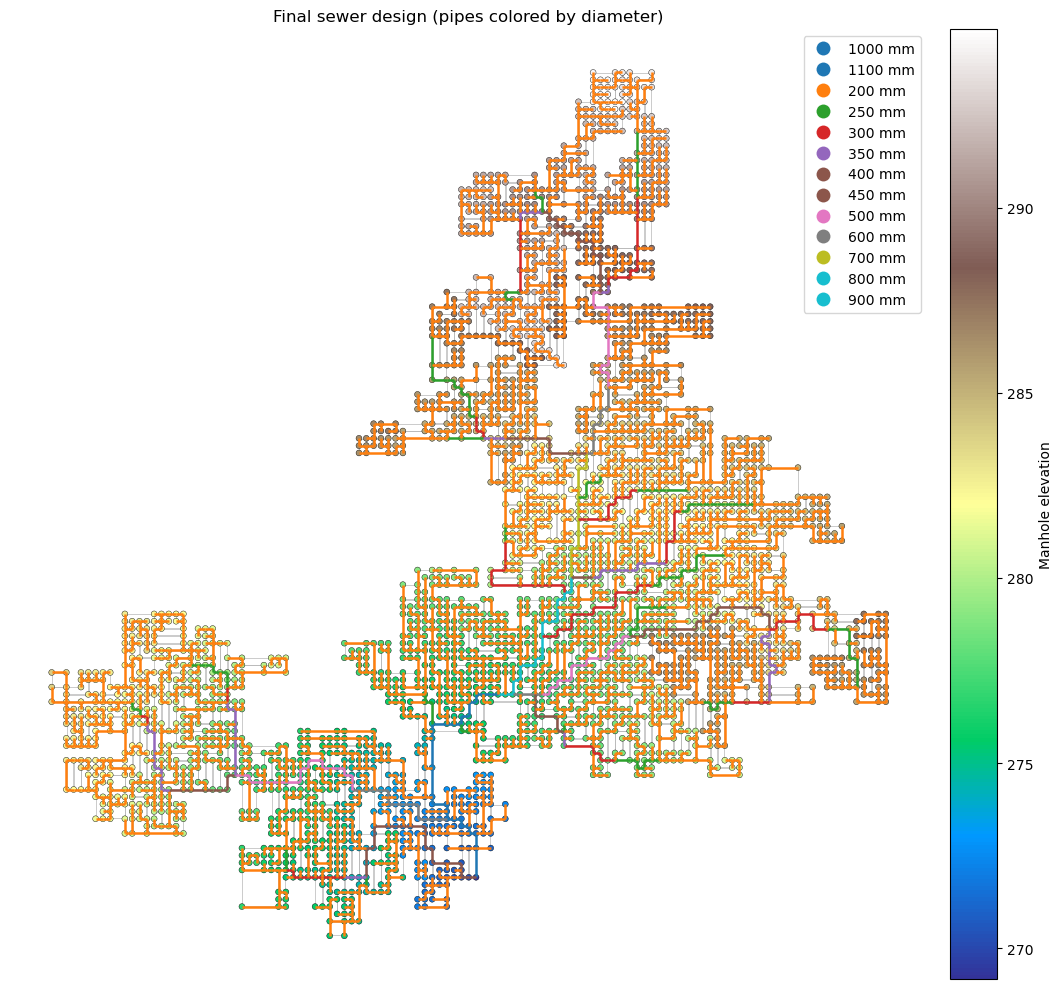

In [10]:
pipes_clean, manholes_clean = project.design_pipes(
    minimum_slope=0.005,
    material_fractions={"PVC": 0.6, "CONCRETE": 0.3, "HDPE": 0.1},
    n_by_material={"PVC": 0.011, "CONCRETE": 0.013, "HDPE": 0.012},
    standard_diameters_mm=[200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    minimum_diameter_mm=200,
    min_cover=1.4,
    min_slope=0.005,
    manhole_drop=0.05,
)

st.plot_final_design_color_by_diameter(
    pipes_path=project.pipes_path,
    manholes_path=project.manholes_path,
    blocks_path=project.blocks_path,
    diameter_field="diameter_mm",
    manhole_color_field="elevation",
    linewidth=1.8,
)


## 10. Dynamic Flow Input Definition

The base SWMM model is exported once. A named scenario then copies that base input into its own folder and applies the same BWF/DWF, GWI, and RDII definitions from `example_02`.


✅ SWMM .inp file written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewer_model.inp
✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/scenarios/bwf_gwi_rdii/sewer_model.inp
SWMM scenario with BWF/DWF patterns created.
✅ INFLOWS section created using coefficient 0.0001. File saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/scenarios/bwf_gwi_rdii/sewer_model.inp


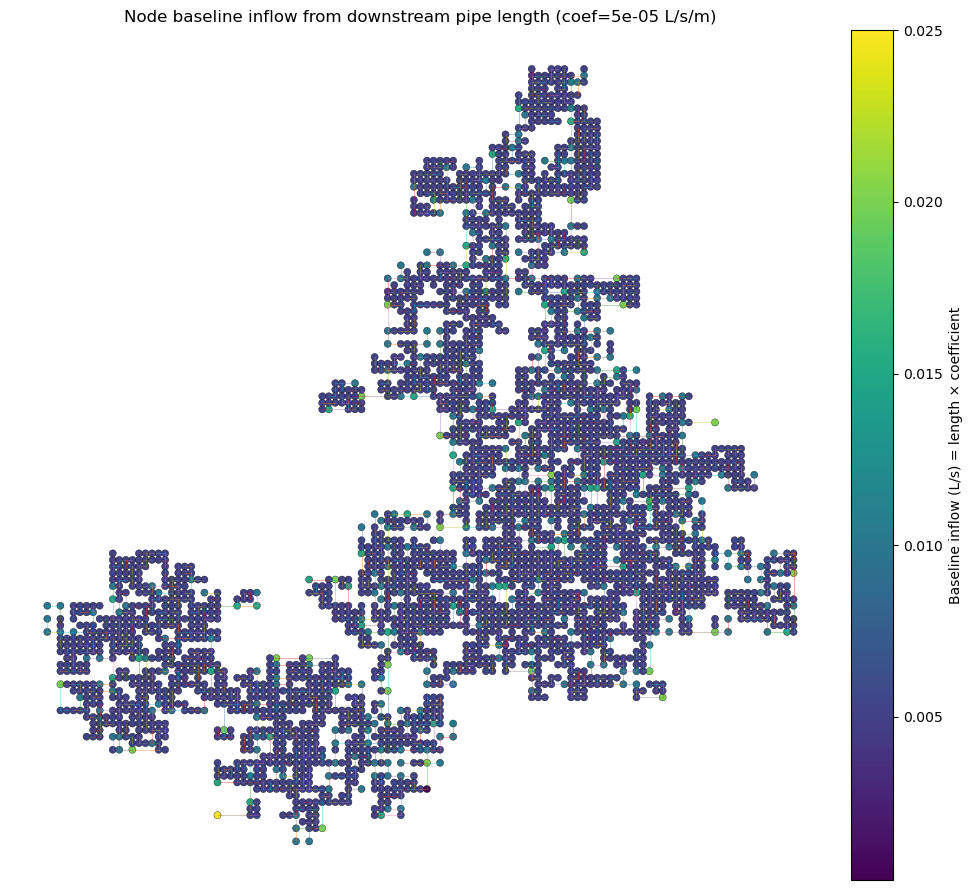

Nodes plotted: 3473
Inflow range: 0.0003 to 0.0250 L/s
✅ SWMM .inp file updated with subcatchments and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/scenarios/bwf_gwi_rdii/sewer_model.inp
Scenario input: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/scenarios/bwf_gwi_rdii/sewer_model.inp


In [11]:
# Ten-day simulation from example_02
routing_step = "0:00:10"
START_DATE = "01/01/2025"
END_DATE = "01/10/2025"

options = {
    "FLOW_UNITS": "LPS",
    "INFILTRATION": "CURVE_NUMBER",
    "FLOW_ROUTING": "KINWAVE",
    "LINK_OFFSETS": "DEPTH",
    "MIN_SLOPE": "0",
    "ALLOW_PONDING": "NO",
    "SKIP_STEADY_STATE": "NO",
    "START_DATE": START_DATE,
    "START_TIME": "00:00:00",
    "REPORT_START_DATE": START_DATE,
    "REPORT_START_TIME": "00:00:00",
    "END_DATE": END_DATE,
    "END_TIME": "00:00:00",
    "SWEEP_START": "01/01",
    "SWEEP_END": "12/31",
    "DRY_DAYS": "0",
    "REPORT_STEP": "00:15:00",
    "WET_STEP": "00:00:10",
    "DRY_STEP": "00:00:10",
    "ROUTING_STEP": routing_step,
    "RULE_STEP": "00:00:00",
    "INERTIAL_DAMPING": "PARTIAL",
    "NORMAL_FLOW_LIMITED": "BOTH",
    "FORCE_MAIN_EQUATION": "D-W",
    "VARIABLE_STEP": "0.75",
    "LENGTHENING_STEP": "0",
    "MIN_SURFAREA": "1.167",
    "MAX_TRIALS": "8",
    "HEAD_TOLERANCE": "0.0015",
    "SYS_FLOW_TOL": "5",
    "LAT_FLOW_TOL": "5",
    "MINIMUM_STEP": "0.5",
    "THREADS": "1",
}
project.export_swmm(options_dict=options)

scenario = project.create_run("bwf_gwi_rdii")

hourly = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.4838, 0.8014,
    1.1337, 1.3239, 1.3321, 1.2512, 1.1900, 1.1703,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.3362, 1.3175, 1.1978, 0.9890, 0.7576,
]
daily_vals = [1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2]
monthly_vals = [0.90, 0.95, 1.00, 1.05, 1.10, 1.10, 1.05, 1.00, 0.95, 0.90, 0.90, 0.90]
fairfax_weekend = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.3568, 0.4068,
    0.6068, 0.7068, 0.8014, 1.1337, 1.3239, 1.3321,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.1362, 1.0175, 0.8978, 0.8090, 0.7576,
]

scenario.assign_dwf_patterns(
    hourly_id="1",
    hourly_values=hourly,
    daily_id="2",
    daily_values=daily_vals,
    monthly_id="3",
    monthly_values=monthly_vals,
    weekend_id="4",
    weekend_values=fairfax_weekend,
)
print("SWMM scenario with BWF/DWF patterns created.")

gwi_coefficient = 0.00005
scenario.assign_gwi_from_pipe_length(coefficient=gwi_coefficient)
st.plot_inflow_from_pipe_length(
    inp_path=scenario.swmm_inp_path,
    coefficient=gwi_coefficient,
)

rainfall_data=[
    ('1/2/2025', '00:00', 0.0), ('1/2/2025', '00:30', 0.2205), ('1/2/2025', '01:00', 0.2205),
    ('1/2/2025', '01:30', 0.3855), ('1/2/2025', '02:00', 0.3855), ('1/2/2025', '02:30', 0.447),
    ('1/2/2025', '03:00', 0.447), ('1/2/2025', '03:30', 0.447), ('1/2/2025', '04:00', 0.447),
    ('1/2/2025', '04:30', 0.4155), ('1/2/2025', '05:00', 0.4155), ('1/2/2025', '05:30', 0.3705),
    ('1/2/2025', '06:00', 0.3705), ('1/2/2025', '06:30', 0.3235), ('1/2/2025', '07:00', 0.3235),
    ('1/2/2025', '07:30', 0.2795), ('1/2/2025', '08:00', 0.2795), ('1/2/2025', '08:30', 0.242),
    ('1/2/2025', '09:00', 0.242), ('1/2/2025', '09:30', 0.211), ('1/2/2025', '10:00', 0.211),
    ('1/2/2025', '10:30', 0.186), ('1/2/2025', '11:00', 0.186), ('1/2/2025', '11:30', 0.1655),
    ('1/2/2025', '12:00', 0.1655), ('1/2/2025', '12:30', 0.148), ('1/2/2025', '13:00', 0.148),
    ('1/2/2025', '13:30', 0.133), ('1/2/2025', '14:00', 0.133), ('1/2/2025', '14:30', 0.12),
    ('1/2/2025', '15:00', 0.12), ('1/2/2025', '15:30', 0.1075), ('1/2/2025', '16:00', 0.1075),
    ('1/2/2025', '16:30', 0.0955), ('1/2/2025', '17:00', 0.0955), ('1/2/2025', '17:30', 0.085),
    ('1/2/2025', '18:00', 0.085), ('1/2/2025', '18:30', 0.0745), ('1/2/2025', '19:00', 0.0745),
    ('1/2/2025', '19:30', 0.0655), ('1/2/2025', '20:00', 0.0655), ('1/2/2025', '20:30', 0.0575),
    ('1/2/2025', '21:00', 0.0575), ('1/2/2025', '21:30', 0.0505), ('1/2/2025', '22:00', 0.0505),
    ('1/2/2025', '22:30', 0.045), ('1/2/2025', '23:00', 0.045), ('1/2/2025', '23:30', 0.0405),
    ('1/3/2025', '00:00', 0.0405), ('1/3/2025', '00:30', 0.0365), ('1/3/2025', '01:00', 0.0365),
    ('1/3/2025', '01:30', 0.034), ('1/3/2025', '02:00', 0.034), ('1/3/2025', '02:30', 0.031),
    ('1/3/2025', '03:00', 0.031), ('1/3/2025', '03:30', 0.0295), ('1/3/2025', '04:00', 0.0295),
    ('1/3/2025', '04:30', 0.027), ('1/3/2025', '05:00', 0.027), ('1/3/2025', '05:30', 0.025),
    ('1/3/2025', '06:00', 0.025), ('1/3/2025', '06:30', 0.022), ('1/3/2025', '07:00', 0.022),
    ('1/3/2025', '07:30', 0.0195), ('1/3/2025', '08:00', 0.0195), ('1/3/2025', '08:30', 0.0165),
    ('1/3/2025', '09:00', 0.0165), ('1/3/2025', '09:30', 0.0135), ('1/3/2025', '10:00', 0.0135),
    ('1/3/2025', '10:30', 0.01), ('1/3/2025', '11:00', 0.01), ('1/3/2025', '11:30', 0.0075),
    ('1/3/2025', '12:00', 0.0075), ('1/3/2025', '12:30', 0.005), ('1/3/2025', '13:00', 0.005),
    ('1/3/2025', '13:30', 0.003), ('1/3/2025', '14:00', 0.003), ('1/3/2025', '14:30', 0.002),
    ('1/3/2025', '15:00', 0.002), ('1/3/2025', '15:30', 0.0005), ('1/3/2025', '16:00', 0.0005),
    ('1/3/2025', '16:30', 0.0), ('1/3/2025', '17:00', 0.0), ('1/3/2025', '17:30', 0.0005),
    ('1/3/2025', '18:00', 0.0005), ('1/3/2025', '18:30', 0.0), ('1/3/2025', '19:00', 0.0),
    ('1/3/2025', '19:30', 0.0), ('1/3/2025', '20:00', 0.0), ('1/3/2025', '20:30', 0.0),
    ('1/3/2025', '21:00', 0.0005), ('1/3/2025', '21:30', 0.0005), ('1/3/2025', '22:00', 0.0005),
    ('1/3/2025', '22:30', 0.0005), ('1/3/2025', '23:00', 0.0), ('1/3/2025', '23:30', 0.0),
    ('1/4/2025', '00:00', 0.0), ('1/4/2025', '00:30', 0.0), ('1/4/2025', '01:00', 0.0),
    ('1/6/2025', '00:00', 0.0), ('1/6/2025', '00:30', 0.312), ('1/6/2025', '01:00', 0.32),
    ('1/6/2025', '01:30', 0.33), ('1/6/2025', '02:00', 0.324), ('1/6/2025', '02:30', 0.302),
    ('1/6/2025', '03:00', 0.27), ('1/6/2025', '03:30', 0.238), ('1/6/2025', '04:00', 0.208),
    ('1/6/2025', '04:30', 0.184), ('1/6/2025', '05:00', 0.168), ('1/6/2025', '05:30', 0.154),
    ('1/6/2025', '06:00', 0.148), ('1/6/2025', '06:30', 0.142), ('1/6/2025', '07:00', 0.136),
    ('1/6/2025', '07:30', 0.132), ('1/6/2025', '08:00', 0.128), ('1/6/2025', '08:30', 0.122),
    ('1/6/2025', '09:00', 0.12), ('1/6/2025', '09:30', 0.116), ('1/6/2025', '10:00', 0.114),
    ('1/6/2025', '10:30', 0.116), ('1/6/2025', '11:00', 0.116), ('1/6/2025', '11:30', 0.114),
    ('1/6/2025', '12:00', 0.116), ('1/6/2025', '12:30', 0.112), ('1/6/2025', '13:00', 0.11),
    ('1/6/2025', '13:30', 0.104), ('1/6/2025', '14:00', 0.102), ('1/6/2025', '14:30', 0.1),
    ('1/6/2025', '15:00', 0.11), ('1/6/2025', '15:30', 0.132), ('1/6/2025', '16:00', 0.172),
    ('1/6/2025', '16:30', 0.236), ('1/6/2025', '17:00', 0.324), ('1/6/2025', '17:30', 0.442),
    ('1/6/2025', '18:00', 0.586), ('1/6/2025', '18:30', 0.754), ('1/6/2025', '19:00', 0.93),
    ('1/6/2025', '19:30', 1.11), ('1/6/2025', '20:00', 1.268), ('1/6/2025', '20:30', 1.392),
    ('1/6/2025', '21:00', 1.46), ('1/6/2025', '21:30', 1.456), ('1/6/2025', '22:00', 1.37),
    ('1/6/2025', '22:30', 1.202), ('1/6/2025', '23:00', 0.964), ('1/6/2025', '23:30', 0.694),
    ('1/7/2025', '00:00', 0.44), ('1/7/2025', '00:30', 0.0), ('1/7/2025', '01:00', 0.0),          
]

# ============================================================
# USER INPUTS
# ============================================================
# P_total = 5.0  # total rainfall depth in mm
# storm_start = "1/2/2025 00:00"

# ============================================================
# SCS / NRCS TYPE II 24-HOUR DISTRIBUTION
# 30-minute cumulative fractions
# ============================================================
# time_hr = [
#     0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5,
#     4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5,
#     8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5,
#     12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5,
#     16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5,
#     20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
#     24.0
# ]

# cum_fraction = [
#     0.000, 0.005, 0.011, 0.017, 0.023, 0.029, 0.035, 0.041,
#     0.048, 0.056, 0.064, 0.072, 0.080, 0.089, 0.098, 0.108,
#     0.120, 0.133, 0.147, 0.163, 0.181, 0.204, 0.235, 0.283,
#     0.500, 0.717, 0.765, 0.796, 0.819, 0.837, 0.853, 0.867,
#     0.880, 0.892, 0.902, 0.911, 0.920, 0.928, 0.936, 0.944,
#     0.952, 0.959, 0.965, 0.971, 0.977, 0.983, 0.989, 0.995,
#     1.000
# ]

# time_hr = [
#     0.0, 1.0, 2.0, 3.0,
#     4.0, 5.0, 6.0, 7.0,
#     8.0, 9.0, 10.0, 11.0,
#     12.0, 13.0, 14.0, 15.0,
#     16.0, 17.0, 18.0, 19.0,
#     20.0, 21.0, 22.0, 23.0,    
#     24.0
# ]

# cum_fraction = [
#     0.000, 0.011, 0.022, 0.035,
#     0.048, 0.063, 0.080, 0.099,
#     0.120, 0.147, 0.181, 0.235,
#     0.663, 0.772, 0.820, 0.854,
#     0.880, 0.902, 0.921, 0.938,
#     0.952, 0.965, 0.977, 0.989,
#     1.000
# ]

# # ============================================================
# # CREATE DATAFRAME
# # ============================================================
# df = pd.DataFrame({
#     "time_hr": time_hr,
#     "cum_fraction": cum_fraction
# })

# df["cum_rain_mm"] = df["cum_fraction"] * P_total
# df["rain_mm"] = df["cum_rain_mm"].diff().fillna(0).round(3)

# # ============================================================
# # CREATE DATE/TIME FORMAT
# # ============================================================
# df["datetime"] = pd.date_range(
#     start=pd.Timestamp(storm_start),
#     periods=len(df),
#     freq="60min"
# )

# rainfall_data = [
#     (
#         dt.strftime("%-m/%-d/%Y"),
#         dt.strftime("%H:%M"),
#         rain
#     )
#     for dt, rain in zip(df["datetime"], df["rain_mm"])
# ]

# # ============================================================
# # PRINT AS PYTHON LIST
# # ============================================================
# print("rainfall_data=[")
# for row in rainfall_data:
#     print(f"    {row},")
# print("]")

scenario.add_subcatchment_rdii(
    raingage_id="1",
    raingage_coords=(500, 500),
    timeseries=rainfall_data,
    interval='0:30',
    n_imperv=0.011,
    n_perv=0.15,
    s_imperv=0.0,
    s_perv=0.0,
    pct_zero=0,
    route_to="OUTLET",
    pct_routed="",
    infiltration_params=(30, 0.5, 7, "", ""),
    imperv_pct=2,
    width=100,
    slope=0.005,
    curblen=0,
)

print("Scenario input:", scenario.swmm_inp_path)


## 11. EPA-SWMM Simulation

The scenario adds the pollutant/component tags used for flow separation, then PySWMM runs the scenario while extracting outlet flow components.


In [12]:
scenario.add_pollutant_tags()
df = scenario.get_flow_components(link_id="P_OUTLET")


✅ Tagged inp written (uses CONCEN) -> /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/scenarios/bwf_gwi_rdii/sewer_model.inp


## 12. Flow Output Decomposition

Flow components are plotted over the same simulation window used in `example_02`, saved to NetCDF inside the scenario folder, and the project metadata is updated.


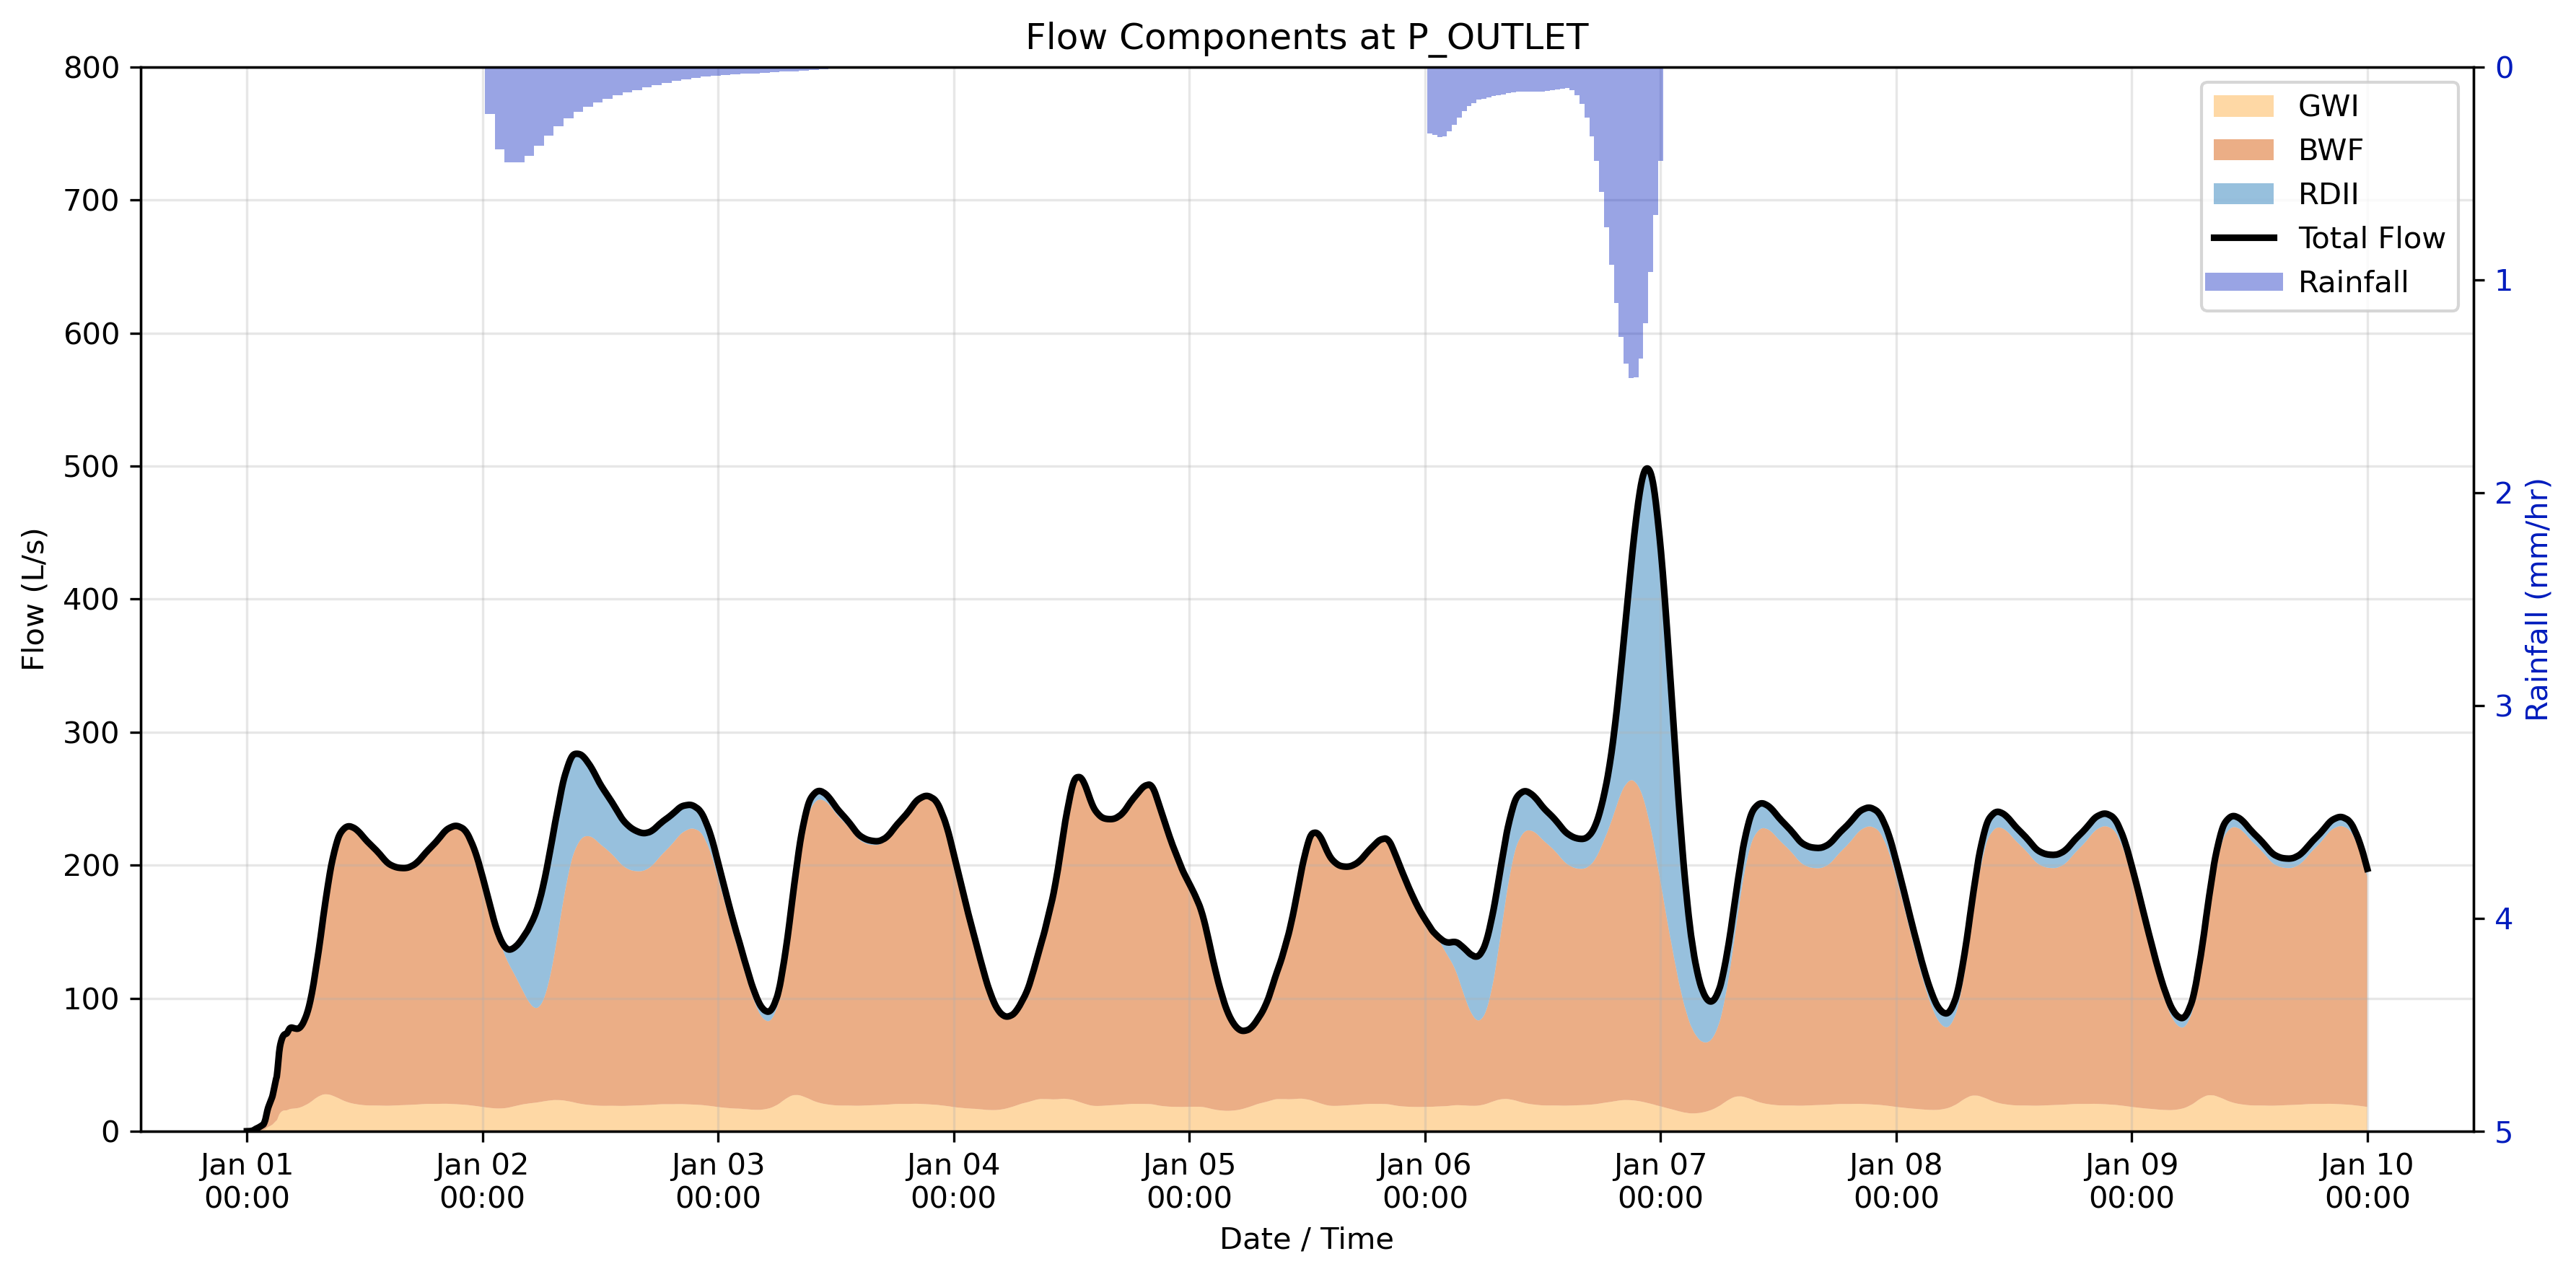

Flow components: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/scenarios/bwf_gwi_rdii/flows.nc
Project metadata: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewertris_project.json


In [13]:
st.plot_flow_components_v2(
    df,
    rain=rainfall_data,
    start=f"{START_DATE} 00:00:00",
    end=f"{END_DATE} 00:00:00",
    flow_units="L/s",
    stack_components=True,
    flow_min=0,
    flow_max=800,
    rain_min=0,
    rain_max=5
)

flows_path = scenario.save_flow_components(df)
project.save()
print("Flow components:", flows_path)
print("Project metadata:", project.project_file)
